## Imports

We import data handling, visualization, and machine learning libraries used for model training and evaluation.[file:1]


In [44]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn           as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score,precision_score,recall_score,f1_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
import scipy.stats as stats
from sklearn.model_selection import GridSearchCV



## Data loading

We load the loan default dataset from CSV into a pandas DataFrame and preview the first few rows to understand its structure and columns

In [45]:
ld = pd.read_csv(r"C:\Users\Asus\Downloads\Machine Learning Projects\Loan_default\Loan_default.csv")

In [46]:
ld.head(10)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
5,A9S62RQ7US,25,90298,90448,720,18,2,22.72,24,0.10,High School,Unemployed,Single,Yes,No,Business,Yes,1
6,H8GXPAOS71,38,111188,177025,429,80,1,19.11,12,0.16,Bachelor's,Unemployed,Single,Yes,No,Home,Yes,0
7,0HGZQKJ36W,56,126802,155511,531,67,4,8.15,60,0.43,PhD,Full-time,Married,No,No,Home,Yes,0
8,1R0N3LGNRJ,36,42053,92357,827,83,1,23.94,48,0.20,Bachelor's,Self-employed,Divorced,Yes,No,Education,No,1
9,CM9L1GTT2P,40,132784,228510,480,114,4,9.09,48,0.33,High School,Self-employed,Married,Yes,No,Other,Yes,0


# About the Data set
LoanID: Unique identifier string for each loan record.
​

Age: Borrower age in years, integer values (e.g., 20–70+).
​

Income: Annual income of the borrower in currency units, continuous numeric.
​

LoanAmount: Principal loan amount sanctioned, continuous numeric.
​

CreditScore: Credit score of the borrower (roughly 300–850 range) indicating creditworthiness.
​

MonthsEmployed: Number of months the borrower has been employed in current/previous job, integer.
​

NumCreditLines: Count of existing credit lines or accounts (cards, loans, etc.).
​

InterestRate: Interest rate on the loan in percentage terms (e.g., around 2–25).
​

LoanTerm: Duration of the loan in months (common values like 12, 24, 36, 48, 60).
​

DTIRatio: Debt‑to‑income ratio, numeric between 0 and 1 representing monthly debt payments / income.
​

Education: Categorical education level (e.g., High School, Bachelor's, Master's, PhD).
​

EmploymentType: Categorical employment type (Full-time, Part-time, Self-employed, Unemployed).
​

MaritalStatus: Categorical marital status (Single, Married, Divorced).
​

HasMortgage: Yes/No flag indicating if the borrower currently has a mortgage.
​

HasDependents: Yes/No flag indicating if the borrower has financial dependents.
​

LoanPurpose: Categorical purpose of loan (Home, Auto, Business, Education, Other).
​

HasCoSigner: Yes/No flag indicating presence of a co‑signer or guarantor on the loan.
​

Default: Target variable; Default = 1 → the loan has gone into default (customer did not pay back as per schedule) Default = 0 → the loan was repaid normally or is not in default.

In [47]:
ld.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

## Data Preprocessing & Categorical Encoding
Machine learning models require numerical input. We have already manually mapped ordinal variables (Education, EmploymentType). Now, we will use `LabelEncoder` to convert the remaining nominal categorical variables (like MaritalStatus, HasMortgage, etc.) into integer format.

In [48]:
# Ordinal Data Replacing Manually 
edu_map = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3
}

emp_map = {
    "Unemployed": 0,
    "Part-time": 1,
    "Full-time": 2,
    "Self-employed": 3
}

ld["Education_enc"] = ld["Education"].map(edu_map)
ld["EmploymentType_enc"] = ld["EmploymentType"].map(emp_map)

In [49]:
ld = ld.drop(["LoanID"], axis = 1)

In [50]:
ld

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Education_enc,EmploymentType_enc
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,1,2
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,2,2
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,2,0
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,0,2
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0,1,2
255343,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1,0,1
255344,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0,0,3
255345,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0,0,1


## Labling Converting all categorincal data into numbers

In [51]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ld[ld.select_dtypes(include ='object').columns] = ld[ld.select_dtypes(include ="object").columns].apply(le.fit_transform)

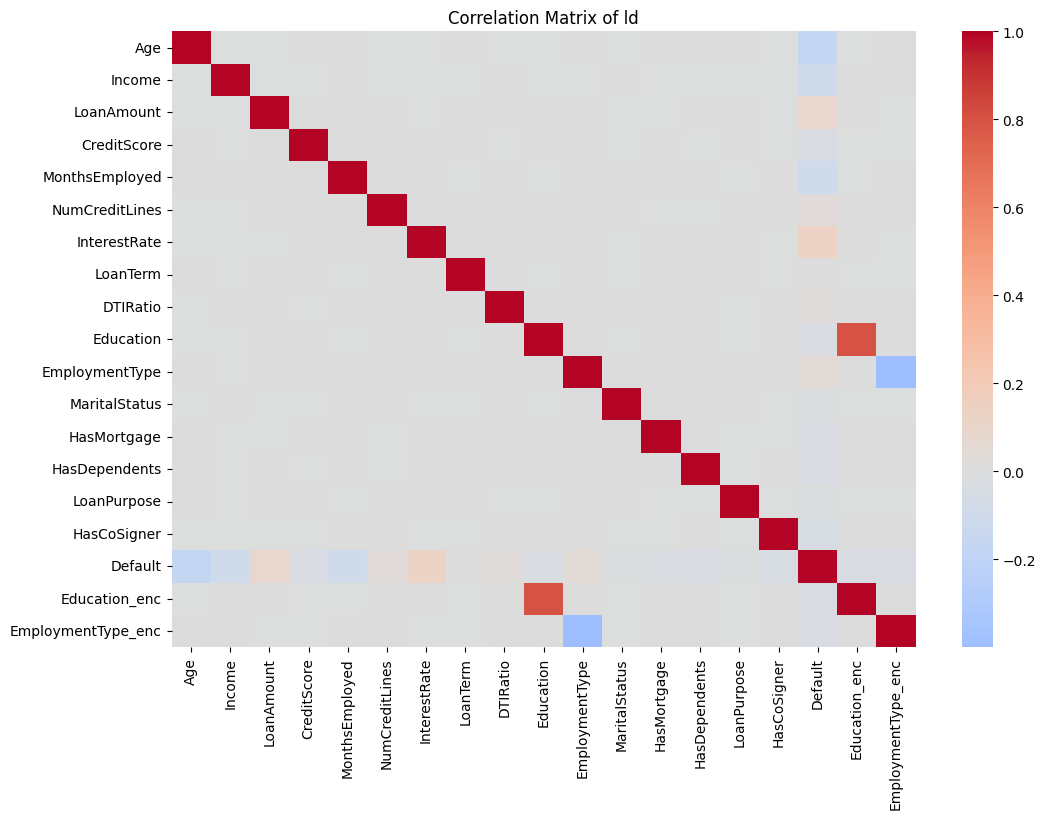

In [52]:
corr = ld.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of ld')
plt.show()  # future exporle

## Train–test split

We split the data into training and test sets so that model performance can be evaluated on unseen samples.

In [53]:
from sklearn.model_selection import train_test_split
ld_train,ld_test=train_test_split(ld,test_size=.2)
ld_train_x = ld_train.drop(["Default"], axis =1)
ld_train_y = ld_train.iloc[:, -3]      
ld_test_x  = ld_test.drop(["Default"], axis =1)
ld_test_y  = ld_test.iloc[:, -3]  

In [54]:
ld_train_y.value_counts()
# there is a class imbalance

Default
0    180652
1     23625
Name: count, dtype: int64

### Modeling Approach 1: Algorithmic Class Weighting
Since our data is highly imbalanced, standard accuracy is a misleading metric. A model that predicts "No Default" every time would yield high accuracy but be useless for a bank. 

We will start by passing `class_weight="balanced"` to our models. This tells the algorithm to heavily penalize mistakes made on the minority class (Defaults). Let's evaluate Logistic Regression, Decision Trees, and Random Forests.

In [55]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(class_weight = "balanced")
logreg.fit(ld_train_x,ld_train_y)
pred=logreg.predict(ld_test_x)
tab=confusion_matrix(ld_test_y,pred)
print(tab)
print("-------------------------------------------------------------------------")
print(classification_report(ld_test_y,pred))

[[30152 14890]
 [ 2098  3930]]
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.67      0.78     45042
           1       0.21      0.65      0.32      6028

    accuracy                           0.67     51070
   macro avg       0.57      0.66      0.55     51070
weighted avg       0.85      0.67      0.73     51070



C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(class_weight = "balanced")
dt.fit(ld_train_x,ld_train_y)
pred=dt.predict(ld_test_x)
tab=confusion_matrix(ld_test_y,pred)
print(tab)
print("-------------------------------------------------------------------------")
print(classification_report(ld_test_y,pred))

[[40471  4571]
 [ 4841  1187]]
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     45042
           1       0.21      0.20      0.20      6028

    accuracy                           0.82     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.81      0.82      0.81     51070



In [57]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(class_weight = "balanced") 
rfc.fit(ld_train_x,ld_train_y)
print("Train accuracy:", rfc.score(ld_train_x,ld_train_y))
pred = rfc.predict(ld_test_x)
tab = confusion_matrix(ld_test_y, pred)
print(tab)
print("________________________________________________")
print(classification_report(ld_test_y,pred))

Train accuracy: 0.9999657328039867
[[44940   102]
 [ 5880   148]]
________________________________________________
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45042
           1       0.59      0.02      0.05      6028

    accuracy                           0.88     51070
   macro avg       0.74      0.51      0.49     51070
weighted avg       0.85      0.88      0.83     51070



In [58]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

X = ld_test_x
y = ld_test_y

logreg = LogisticRegression(
    class_weight="balanced",
    C=0.01,
    fit_intercept=True,
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(logreg, X, y, cv=skf, scoring="f1")
roc_scores = cross_val_score(logreg, X, y, cv=skf, scoring="roc_auc")

print("F1 per fold:", f1_scores)
print("Mean F1:", f1_scores.mean())
print("ROC-AUC per fold:", roc_scores)
print("Mean ROC-AUC:", roc_scores.mean())

C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

F1 per fold: [0.32542098 0.32970643 0.33446148 0.33978407 0.33048659]
Mean F1: 0.33197190895891365
ROC-AUC per fold: [0.73016555 0.73514296 0.74929388 0.75467117 0.74107151]
Mean ROC-AUC: 0.7420690140597183


##  Modeling Approach 2: Data-Level Oversampling
Instead of relying on algorithmic weighting, let's try physically balancing the dataset. We will extract the minority class (Defaults) and duplicate it 7 times in our training set. This will force the models to learn the patterns of defaulters by exposing them to more examples.

In [28]:
# Take only minority class
df1 = ld_train[ld_train["Default"] == 1]

# Fixing class imbalance by duplicating minority class 7 times
ld_train1 = pd.concat([ld_train, df1, df1, df1, df1, df1, df1, df1], axis=0)

# Shuffle (optional but recommended)
ld_train1 = ld_train1.sample(frac=1, random_state=42).reset_index(drop=True)

# New X, y
ld_train_x1 = ld_train1.drop(["Default"], axis=1)
ld_train_y1 = ld_train1["Default"]


In [34]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression()
logreg.fit(ld_train_x1,ld_train_y1)
pred=logreg.predict(ld_test_x)
tab=confusion_matrix(ld_test_y,pred)
print(tab)
print("-------------------------------------------------------------------------")
print(classification_report(ld_test_y,pred))

[[28247 16911]
 [ 1994  3918]]
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.63      0.75     45158
           1       0.19      0.66      0.29      5912

    accuracy                           0.63     51070
   macro avg       0.56      0.64      0.52     51070
weighted avg       0.85      0.63      0.70     51070



C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [35]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(ld_train_x1,ld_train_y1)
pred=dt.predict(ld_test_x)
tab=confusion_matrix(ld_test_y,pred)
print(tab)
print("-------------------------------------------------------------------------")
print(classification_report(ld_test_y,pred))

[[40605  4553]
 [ 4776  1136]]
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     45158
           1       0.20      0.19      0.20      5912

    accuracy                           0.82     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.81      0.82      0.82     51070



In [38]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(class_weight = "balanced",C = 1, penalty = 'l1', solver='liblinear',max_iter=1000)
logreg.fit(ld_train_x,ld_train_y)
pred=logreg.predict(ld_test_x)
tab=confusion_matrix(ld_test_y,pred)
print(tab)
print("-------------------------------------------------------------------------")
print(classification_report(ld_test_y,pred))

C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[[30448 14710]
 [ 1843  4069]]
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45158
           1       0.22      0.69      0.33      5912

    accuracy                           0.68     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.68      0.73     51070



In [39]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier() 
rfc.fit(ld_train_x,ld_train_y)
print("Train accuracy:", rfc.score(ld_train_x1,ld_train_y1))
pred = rfc.predict(ld_test_x)
tab = confusion_matrix(ld_test_y, pred)
print(tab)
print("________________________________________________")
print(classification_report(ld_test_y,pred))

Train accuracy: 0.9998488382136996
[[45007   151]
 [ 5652   260]]
________________________________________________
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45158
           1       0.63      0.04      0.08      5912

    accuracy                           0.89     51070
   macro avg       0.76      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



In [40]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(C = 1, penalty = 'l1', solver='liblinear',max_iter=1000)
logreg.fit(ld_train_x,ld_train_y)
pred=logreg.predict(ld_test_x)
tab=confusion_matrix(ld_test_y,pred)
print(tab)
print("-------------------------------------------------------------------------")
print(classification_report(ld_test_y,pred))

C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[[45030   128]
 [ 5698   214]]
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45158
           1       0.63      0.04      0.07      5912

    accuracy                           0.89     51070
   macro avg       0.76      0.52      0.50     51070
weighted avg       0.86      0.89      0.84     51070



##  Hyperparameter Tuning
Using our balanced dataset, we will fine-tune our Logistic Regression model (which showed the most promising recall for defaults) using `GridSearchCV`. We will test different regularization strengths (`C`), penalties (`l1`, `l2`), and intercept settings to optimize the F1-score.

In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

X = ld_train_x
y = ld_train_y

logreg = LogisticRegression(class_weight = "balanced",solver="liblinear", max_iter=1000)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
      "fit_intercept": [True, False] 
}

logreg_grid = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

logreg_grid.fit(X, y)

print("Best params:", logreg_grid.best_params_)
best_logreg = logreg_grid.best_estimator_


C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best params: {'C': 10, 'fit_intercept': True, 'penalty': 'l1'}


In [42]:
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.linear_model import LogisticRegression
logreg=LogisticRegression(class_weight = "balanced",C = 0.01, fit_intercept = True, penalty = 'l1', solver='liblinear',max_iter=1000)
logreg.fit(ld_train_x,ld_train_y)
pred=logreg.predict(ld_test_x)
tab=confusion_matrix(ld_test_y,pred)
print(tab)
print("-------------------------------------------------------------------------")
print(classification_report(ld_test_y,pred))

C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[[30474 14684]
 [ 1843  4069]]
-------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45158
           1       0.22      0.69      0.33      5912

    accuracy                           0.68     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.68      0.73     51070



In [43]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

X = ld_test_x
y = ld_test_y

logreg = LogisticRegression(
    C=0.01,
    fit_intercept=True,
    penalty="l1",
    solver="liblinear",
    max_iter=1000
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(logreg, X, y, cv=skf, scoring="f1")
roc_scores = cross_val_score(logreg, X, y, cv=skf, scoring="roc_auc")

print("F1 per fold:", f1_scores)
print("Mean F1:", f1_scores.mean())
print("ROC-AUC per fold:", roc_scores)
print("Mean ROC-AUC:", roc_scores.mean())

C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=

F1 per fold: [0.05681818 0.05497171 0.06153846 0.07424961 0.0534413 ]
Mean F1: 0.06020384993963742
ROC-AUC per fold: [0.75265675 0.73806453 0.75374969 0.73662513 0.73776659]
Mean ROC-AUC: 0.7437725368907795


C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## Conclusion & Future Work

### Project Summary
In this project, we set out to build a machine learning model capable of predicting loan defaults. The primary challenge was the severe **class imbalance** in the dataset (180,536 non-defaults vs. 23,741 defaults), which naturally biases models toward predicting the majority class. 

To address this, we explored two main strategies:
1. **Algorithmic Penalization:** Using `class_weight="balanced"` to heavily penalize misclassifications of the minority class.
2. **Data-Level Oversampling:** Manually duplicating the minority class records to physically balance the training distribution.

### Model Evaluation
We tested Logistic Regression, Decision Trees, and Random Forests. Based on the evaluation metrics, we observed the following:
* **Random Forest Overfitting:** Despite achieving near 100% accuracy on the training data, the Random Forest model completely failed to generalize, yielding a dismal recall (3-4%) and F1-score (5-8%) for the minority class. 
* **Logistic Regression as the Best Fit:** Logistic Regression consistently outperformed the complex tree-based models for this specific task. While its overall accuracy dropped to around 67-68%, it successfully identified ~66-69% of the actual defaults (Recall). In a banking context, capturing 69% of potential defaults is far more valuable than having a high overall accuracy that misses all the risky loans.
* **Stable ROC-AUC:** After cross-validation, our tuned Logistic Regression model (with L1 regularization) maintained a stable Mean ROC-AUC score of ~0.74, indicating a reasonable ability to distinguish between defaulters and non-defaulters.

### Business Impact
The final Logistic Regression model provides a conservative, risk-averse approach. By prioritizing **Recall** over Precision, the bank can successfully flag a majority of high-risk loans for manual review, ultimately minimizing financial losses. 

### Future Work
To further improve the model's predictive power, future iterations could explore:
* **Advanced Resampling Techniques:** Implementing SMOTE (Synthetic Minority Over-sampling Technique) instead of simple manual duplication to create synthetic, diverse examples of defaulters.
* **Ensemble Methods:** Testing Gradient Boosting algorithms like XGBoost or LightGBM, which often handle imbalanced tabular data better than standard Random Forests.
* **Feature Engineering:** Creating interaction terms (e.g., `LoanAmount` * `InterestRate`) or grouping continuous variables (like `Age` or `Income` bins) to capture non-linear relationships.